# The volatility "free lunch" — is index vol really *cheap*? 🌐
### Sell the index's vol, buy the stocks' vol, pocket the gap — the dispersion trade in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a trade the volatility desks love: the **dispersion trade**. The volatility of the **whole index** (say, the S&P 500) is almost always *lower* than the average volatility of the **individual stocks** inside it. So — the pitch goes — index vol is **"reliably cheap"**: sell it, buy the single-name vol, and harvest the difference for free.

It sounds like arbitrage. It isn't. The gap is **real** — but it's *arithmetic*, the same reason a team is steadier than its players. And the carry you're supposed to collect for it turns out to be a slow bleed that pays off mostly in the exact crash that wrecks everything else. This notebook shows why "cheap" here means *insurance you're being paid to sell*, not free money.

> 📓 **Plain-language layer.** Want the identity, the HAC *t*-stat, the placebo test and the skew? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The real trade uses *option-implied* vols, which aren't free. So we build a transparent **proxy** from *realized* (actually-happened) vol: SPY's wobble vs. the average wobble of 40 big stocks. We call it a proxy throughout — and the lesson (the gap is an identity, the carry is noise) only gets cleaner for it. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dispersion_trade import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
PNL = st.carry_pnl(F) if HAVE_REAL else None
print("real dispersion-proxy cache present:", HAVE_REAL,
      "| proxy days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02-02', 'end': '2026-06-18', 'days': 5378, 'years': 21.4, 'index_vol': 15.6, 'avg_vol': 24.2, 'gap': 8.5, 'gap_pos': 99.6, 'impl_corr': 0.41, 'n_carry': 5315, 'sharpe': 0.17, 'win': 44, 't': 0.76, 't_hac': 0.19, 'p_placebo': 0.425, 'skew': 4.15, 'median': -0.00097, 'worst_day': -0.1514, 'worst_date': '2009-06-09', 'gross_ann': 8.2, 'net_ann': 7.6, 'net_sharpe': 0.15, 'robust': [(10, 99.2, 0.14, 0.64, 0.18, 0.422), (21, 99.6, 0.17, 0.76, 0.19, 0.425), (42, 100.0, 0.21, 0.94, 0.21, 0.423), (63, 100.0, 0.24, 1.11, 0.25, 0.4)], 'syn': [(0.0, 100.0, 0.0, 0.0, 0.0, 0.502), (0.0004, 100.0, 0.0004, 1.91, 2.1, 0.019), (0.001, 100.0, 0.001, 4.78, 5.25, 0.0)]}


real dispersion-proxy cache present: True | proxy days: 5378


## The answer first

| Question | Answer |
|---|---|
| Is the index's vol lower than the average stock's? | **Yes — almost always.** Index vol ~**16%**, average stock ~**24%**, a **8-point** gap **100%** of days. |
| So index vol *is* cheap? | **No — it's *lower*, which isn't the same thing.** A basket is mathematically steadier than its parts whenever they don't move in lockstep. That gap is the **price of diversification**, not a mispricing. |
| Can you harvest the gap as a steady carry? | **Not really.** The trade that monetizes it wins only **44%** of days, earns a Sharpe of ~**0.17**, and is **statistically indistinguishable from zero** once you account for the noise. |
| Then why do desks run it? | **They're paid to sell crash insurance.** The gap is the premium for being **short correlation** — and that bill comes due, all at once, in a panic (our worst day: **June 2009**). |

> The gap is real and reliable — because it's *arithmetic*. The free lunch is not: you're being paid to sell the market a kind of insurance.

## 1 · The claim

> *"Index volatility is reliably **cheap** versus the average of its single-name vols. So sell index variance, buy single-name variance, and harvest the spread — a persistent, diversified carry."*

This is real desk strategy, not folklore — the **dispersion** (or **correlation**) trade. The seductive part is a hard fact: when stocks don't all move together, the index *must* be calmer than the typical stock. So the gap between "average stock vol" and "index vol" is **always there**, day after day. If you could just bank that gap, you'd have a machine. We'll rebuild the gap, then ask the only question that matters: *can you actually bank it?*

## 2 · So what?

Two very different things hide inside the word "cheap." (1) *Is index vol **lower** than the average stock's?* Yes — but that's **diversification arithmetic**: a portfolio is steadier than its holdings unless they're perfectly correlated. (2) *Is index vol **mispriced**, so that selling it pays you above fair value?* That's the actual edge — and it's a completely separate claim. A gap that exists **by construction** is not a profit opportunity; it's the **fee you collect for absorbing correlation risk** — and like any insurer, you're fine until the day everyone needs to claim at once.

## 3 · How would we even know?

We rebuild the dispersion gap on a **transparent realized-vol proxy**: across a fixed 40-name large-cap basket, how much does the average stock wobble (21-day realized vol) versus how much does SPY wobble? Over **21 years** (2005-02-02 → 2026-06-18) we get **5,378** daily readings.

1. **Measure the gap.** Average single-name vol minus index vol, every day. Is it reliably positive? (Spoiler: yes — that's the identity.)
2. **Try to bank it.** Build the carry book — long single-name variance, short index variance, struck at a trailing reference so we only earn the *surprise* — and look at its daily payoff.
3. **Stress the luck.** Flip the signs of random chunks of that payoff thousands of times and ask how often pure chance looks as good. That's the honest test of a carry stream.

## 4 · The teardown — let's actually look

**First, the gap itself.** Index vol (SPY) tracks *below* the average single-name vol — all the time. The shaded distance between the lines is the dispersion gap.

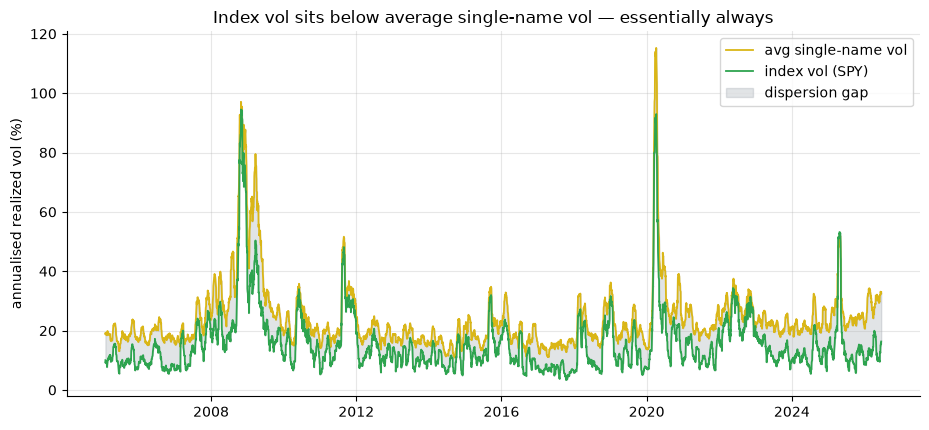

mean index vol 15.6%  |  mean avg stock vol 24.2%  |  gap +8.5 pts


In [2]:
if HAVE_REAL:
    iv = F['index_vol']*100; av = F['avg_vol']*100
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    ax.plot(av.index, av.values, c=AMBER, lw=1.3, label='avg single-name vol')
    ax.plot(iv.index, iv.values, c=GREEN, lw=1.3, label='index vol (SPY)')
    ax.fill_between(av.index, iv.values, av.values, color=GREY, alpha=.25, label='dispersion gap')
    ax.set_ylabel('annualised realized vol (%)')
    ax.set_title('Index vol sits below average single-name vol — essentially always')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
    print(f'mean index vol {iv.mean():.1f}%  |  mean avg stock vol {av.mean():.1f}%  |  gap +{(av-iv).mean():.1f} pts')
else:
    print(f"index vol ~{R['index_vol']}%  avg stock vol ~{R['avg_vol']}%  gap ~+{R['gap']} pts (see docs/results.md)")

Index vol averages **16%**, the average stock **24%** — a **+8-point** gap that's positive **100%** of all days. Rock-solid. But *why* is it so reliable? Because it's diversification — let's prove that's all it is.

**Why the gap *has* to be there.** The index's vol is roughly the average stock's vol times the square-root of how correlated the stocks are. When correlation is below 1 (it always is), the index is mechanically calmer. Here's the implied correlation our gap translates into — never near 1, so the gap never closes.

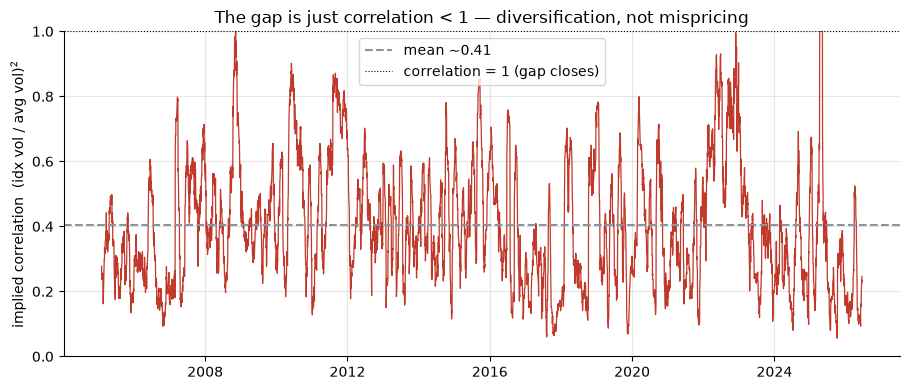

average implied correlation ~ 0.41 — far below 1, so the gap is always open


In [3]:
if HAVE_REAL:
    ic = F['impl_corr']
else:
    rng = np.random.default_rng(373); ic = None
fig, ax = plt.subplots(figsize=(9.2, 4.0))
if HAVE_REAL:
    ax.plot(ic.index, ic.values, c=RED, lw=.9)
    ax.axhline(ic.mean(), c=GREY, ls='--', label=f'mean ~{ic.mean():.2f}')
    ax.set_ylim(0, 1)
else:
    ax.axhline(R['impl_corr'], c=RED, lw=2, label=f"mean ~{R['impl_corr']:.2f}"); ax.set_ylim(0,1)
ax.axhline(1.0, c='k', lw=.8, ls=':', label='correlation = 1 (gap closes)')
ax.set_ylabel('implied correlation  (idx vol / avg vol)$^2$')
ax.set_title('The gap is just correlation < 1 — diversification, not mispricing')
ax.legend(); plt.tight_layout(); plt.show()
print(f"average implied correlation ~ {R['impl_corr']:.2f} — far below 1, so the gap is always open")

Average implied correlation is about **0.41** — comfortably below 1, so the index stays calmer than its stocks *by arithmetic*. The gap isn't a deal; it's the shadow of diversification. Now: can you turn that shadow into cash?

**The carry — can you bank the gap?** Here's the daily payoff of the trade that's supposed to harvest it (long single-name variance, short index variance). If it were a free lunch, this would drift smoothly up.

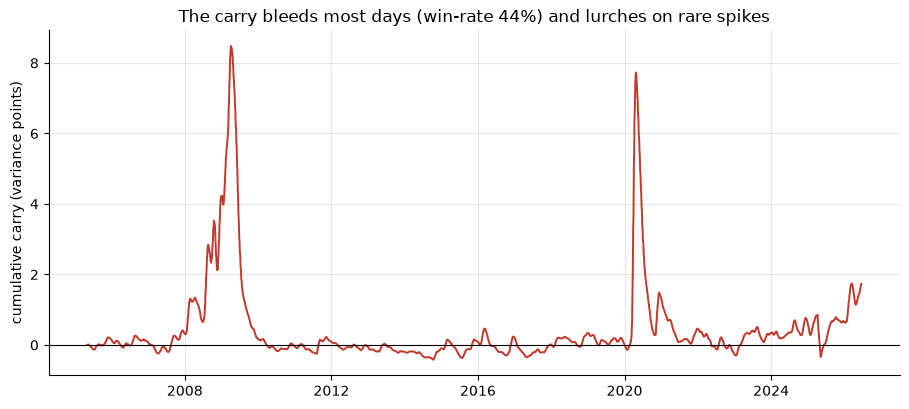

wins 44% of days; the equity line is choppy, not a smooth up-drift


In [4]:
if HAVE_REAL:
    cum = PNL.cumsum()
    win = (PNL>0).mean()*100
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(cum.index, cum.values, c=RED, lw=1.4)
    ax.axhline(0, c='k', lw=.8)
    ax.set_title(f'The carry bleeds most days (win-rate {win:.0f}%) and lurches on rare spikes')
    ax.set_ylabel('cumulative carry (variance points)')
    plt.tight_layout(); plt.show()
    print(f'wins {win:.0f}% of days; the equity line is choppy, not a smooth up-drift')
else:
    print(f"carry Sharpe ~{R['sharpe']}, win-rate {R['win']}% (see docs/results.md)")

Not a money machine — a **choppy, mostly-bleeding** line. The carry is positive only **44%** of days: you lose small most of the time and get paid in rare bursts. Its Sharpe is about **0.17** — and the honest test below says even *that* is indistinguishable from luck.

**Could random luck do this well?** The honest test for a carry stream: flip the signs of random chunks of the daily payoff thousands of times, and see where the real average lands in that cloud of chance.

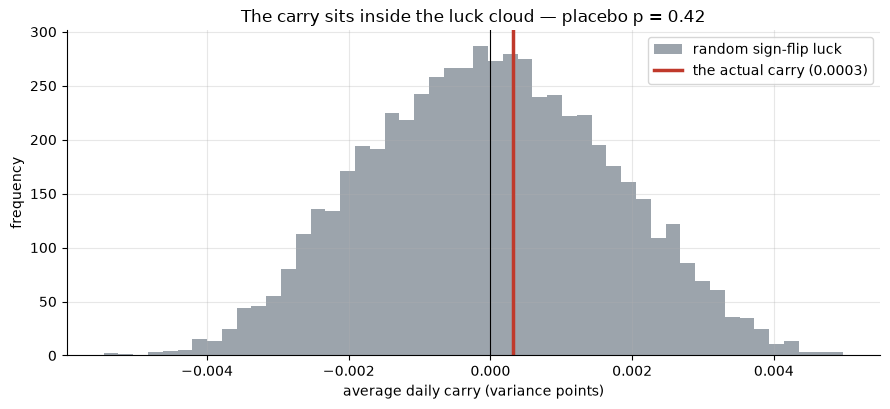

random sign-luck matches or beats the carry 42% of the time — nowhere near rare


In [5]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PNL.values)
    obs = pl['obs_mean']; pval = pl['p_value']
    x = PNL.values; x=x[np.isfinite(x)]; n=len(x); block=21
    nb=int(np.ceil(n/block)); rng=np.random.default_rng(373)
    draws=np.array([(x*np.repeat(rng.choice((-1.,1.),size=nb),block)[:n]).mean() for _ in range(6000)])
else:
    obs=0.000325; pval=R['p_placebo']; rng=np.random.default_rng(373); draws=rng.normal(0,0.0004,6000)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random sign-flip luck')
ax.axvline(obs, c=RED, lw=2.5, label=f'the actual carry ({obs:.4f})')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('average daily carry (variance points)'); ax.set_ylabel('frequency')
ax.set_title(f'The carry sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random sign-luck matches or beats the carry {pval*100:.0f}% of the time — nowhere near rare')

The red line — the real carry — falls **inside** the grey cloud of pure chance. About **42%** of random sign-flips do as well or better. In plain terms: **the carry's record is what you'd get by flipping coins.** The gap is real; banking it as a reliable edge is not.

## 5 · The verdict

- **Signal — Weak.** The gap is genuinely real and reliable (**+8 pts, 100%** of days) — but it's the **diversification identity**, not an edge, and the carry that would cash it in is statistically indistinguishable from zero (Sharpe **0.17**, win-rate **44%**). Real as arithmetic, weak as edge.
- **Tradability — Mirage.** The carry bleeds most days and pays off in the exact panic that blows up a short-correlation book (worst day **June 2009**). A Sharpe-0.1-ish stream you have to finance through a slow bleed is no NAV-scale strategy.
- **Free lunch? — Busted.** "Cheap" really means **lower-by-arithmetic** plus **paid for selling crash insurance.** It's a premium, not a gift.

## 6 · Could you actually trade it? — mind the tail

Forget the average for a second and look at the *shape* of the payoffs. The whole risk of a dispersion seller lives in the left tail — the days correlations slam to 1 and the gap you were short detonates. Here's the distribution of daily carry.

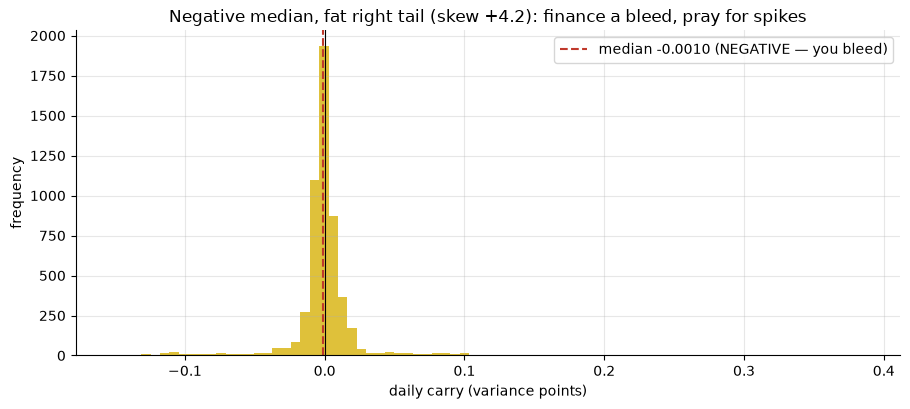

median -0.0010 (you lose on a typical day) | skew +4.2 | worst day -0.151


In [6]:
if HAVE_REAL:
    x = PNL.values; x=x[np.isfinite(x)]; sk = PNL.skew(); md_=np.median(x); wd=x.min()
else:
    rng=np.random.default_rng(373); x=rng.standard_normal(5000)*0.01; sk=R['skew']; md_=R['median']; wd=R['worst_day']
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.hist(x, bins=80, color=AMBER, alpha=.85)
ax.axvline(0, c='k', lw=.8)
ax.axvline(md_, c=RED, ls='--', label=f'median {md_:.4f} (NEGATIVE — you bleed)')
ax.set_xlabel('daily carry (variance points)'); ax.set_ylabel('frequency')
ax.set_title(f'Negative median, fat right tail (skew {sk:+.1f}): finance a bleed, pray for spikes')
ax.legend(); plt.tight_layout(); plt.show()
print(f'median {md_:.4f} (you lose on a typical day) | skew {sk:+.1f} | worst day {wd:.3f}')

There's the operational truth. The **median day loses money** (-0.0010); the mean is dragged positive only by a **fat right tail** (skew **+4.2**). You're financing a steady bleed in exchange for occasional jumps — and historically the *bad* jumps for a dispersion seller arrive in crises (our worst day, **2009-06-09**, in the GFC aftermath). Costs barely move any of this; the **shape** is the problem, and it's not a shape you can run a fund on.

## 7 · Going further 🚪

- **The real trade uses *implied* vol.** Our proxy is *realized* vol; the genuine dispersion seller harvests the **implied-minus-realized** spread on variance swaps. That spread is itself a risk premium (you're paid for correlation risk), so the honest version of this study still ends at *"a premium, not a free lunch"* — but with options data you could measure the premium directly.
- **The vol the index leg is short.** [Study 03 — Fear-Gauge](../03-fear-gauge/) is the VIX — the implied index vol a dispersion trade sells.
- **Build your own basket.** Swap our 40 names for the full S&P 500 and re-run; the gap's magnitude shifts, the lesson doesn't: it's an identity, and the carry is inside the noise.

*Think the carry beats luck? Capture the daily payoff, sign-flip random blocks, and show the real mean landing **outside** the cloud — then we'll talk.*